c:\Users\User\anaconda3\envs\poke\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\User\anaconda3\envs\poke\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\User\anaconda3\envs\poke\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using


--- Model Evaluation Metrics ---


,Model,R² Score,RMSE,MAE
0,Linear Regression,0.923294,0.310511,0.267569
1,Random Forest,0.999899,0.011283,0.000416
2,Regressor,0.999899,0.011283,0.000416


C:\Users\User\AppData\Local\Temp\ipykernel_13876\3470807272.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='R² Score', ax=axes[0], palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_13876\3470807272.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[1], palette='magma')
C:\Users\User\AppData\Local\Temp\ipykernel_13876\3470807272.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='MAE', ax=axes[2], palette='plasma')


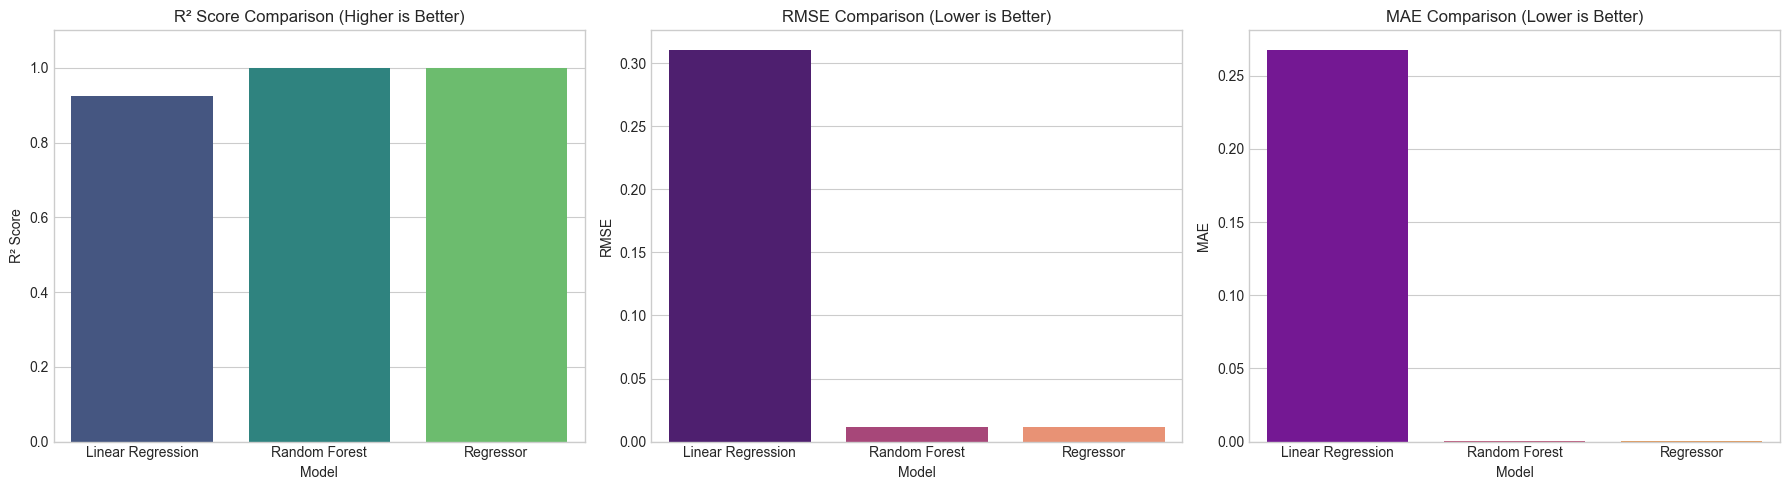

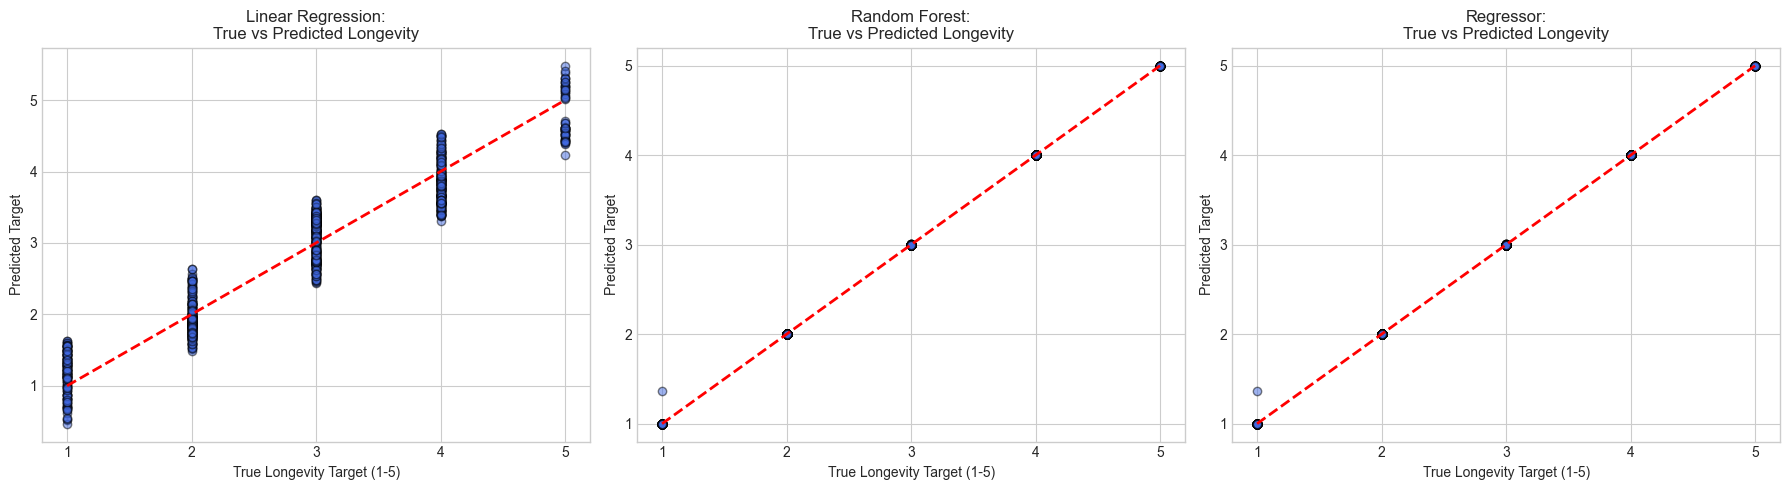

In [9]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from IPython.display import display

# ---------------------------------------------------------
# 1. Load and Prep Data
# ---------------------------------------------------------
# Adjust this path if your dataset is located elsewhere!
df = pd.read_csv('../data/final_processed_dataset.csv') 

# Recreate the actual target variable
def bst_to_generations(bst):
    if bst < 300: return 1
    elif bst < 400: return 2
    elif bst < 500: return 3
    elif bst < 600: return 4
    else: return 5

df['longevity_target'] = df['base_stat_total'].apply(bst_to_generations)
y = df['longevity_target']

# Calculate missing features expected by the models
avg_bst = df['base_stat_total'].mean()
df['stat_efficiency'] = df['base_stat_total'] / avg_bst
df['type_coverage'] = df['num_types'] 

# ---------------------------------------------------------
# 2. Load Models & Features
# ---------------------------------------------------------
# Updated to include all 3 models with the correct relative paths
model_files = {
    'Linear Regression': '../models/longevity_LinearRegression.joblib',
    'Random Forest': '../models/longevity_RandomForest.joblib',
    'Regressor': '../models/longevity_regressor.joblib'
}
models = {name: joblib.load(path) for name, path in model_files.items()}

# Ensure exact feature order based on the first model
expected_features = models['Linear Regression'].feature_names_in_
X = df[expected_features]

# ---------------------------------------------------------
# 3. Evaluate Models
# ---------------------------------------------------------
results = []
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X)
    predictions[name] = y_pred
    
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    
    results.append({
        'Model': name,
        'R² Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })

results_df = pd.DataFrame(results)
print("\n--- Model Evaluation Metrics ---")
display(results_df)

# ---------------------------------------------------------
# 4. Visualizations
# ---------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R2 Score (Higher is better)
sns.barplot(data=results_df, x='Model', y='R² Score', ax=axes[0], palette='viridis')
axes[0].set_title('R² Score Comparison (Higher is Better)')
axes[0].set_ylim(0, 1.1)

# RMSE (Lower is better)
sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[1], palette='magma')
axes[1].set_title('RMSE Comparison (Lower is Better)')

# MAE (Lower is better)
sns.barplot(data=results_df, x='Model', y='MAE', ax=axes[2], palette='plasma')
axes[2].set_title('MAE Comparison (Lower is Better)')

plt.tight_layout()
plt.show()

# Scatter Plots (True vs Predicted)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(predictions.items()):
    axes[i].scatter(y, y_pred, alpha=0.5, color='royalblue', edgecolor='k')
    axes[i].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) 
    axes[i].set_title(f'{name}:\nTrue vs Predicted Longevity')
    axes[i].set_xlabel('True Longevity Target (1-5)')
    axes[i].set_ylabel('Predicted Target')
    axes[i].set_yticks([1, 2, 3, 4, 5])
    axes[i].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()